In [32]:
import pandas as pd
import numpy as np

In [4]:
dataset = pd.read_csv('AAPL_2006-01-01_to_2018-01-01.csv', index_col = 'Date', parse_dates = ['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL


In [5]:
dataset[:'2007-01-01']

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL
...,...,...,...,...,...,...
2006-12-22,11.92,12.01,11.66,11.74,153402130,AAPL
2006-12-26,11.74,11.80,11.56,11.64,122782926,AAPL
2006-12-27,11.16,11.71,10.97,11.65,485160788,AAPL


# Plot the high values of this stock.

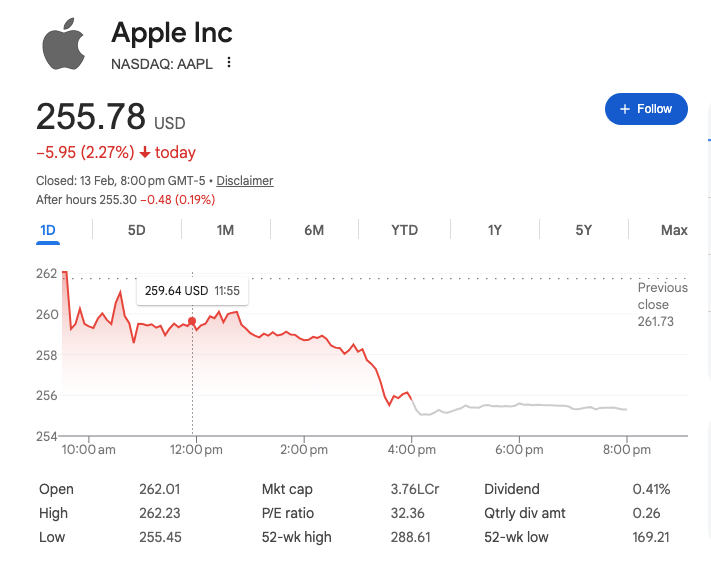

In [6]:
from matplotlib import pyplot as plt

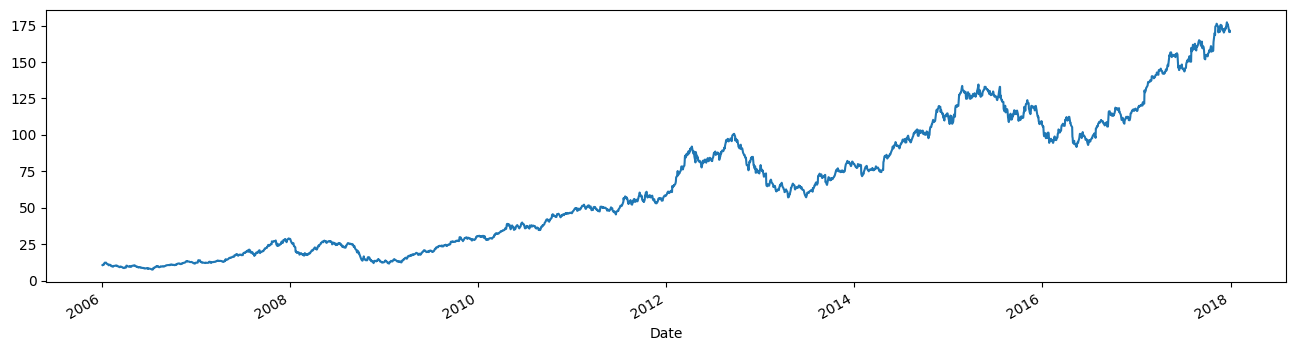

In [7]:
# plot all the high values
dataset['High'].plot(figsize=(16,4))
plt.show()

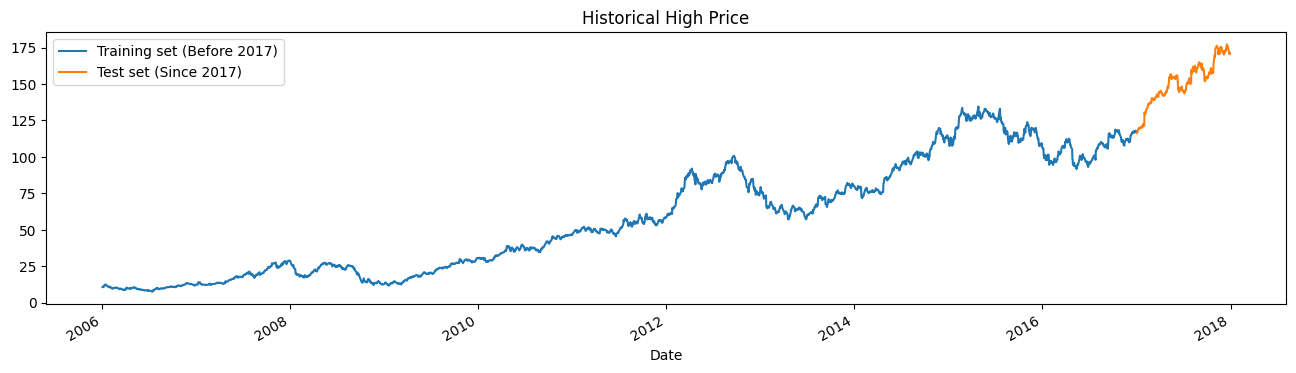

In [8]:
# plot all the high values
dataset['High'][:'2016'].plot(figsize=(16,4), legend=True)
dataset['High']['2017':].plot(figsize=(16,4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (Since 2017)'])
plt.title('Historical High Price')
plt.show()

In [9]:
# We will split the data into train and test
training_set=dataset[:'2016'].iloc[:,1:2].values
test_set=dataset['2017':].iloc[:,1:2].values

In [10]:
training_set.shape, test_set.shape

((2768, 1), (251, 1))

In [11]:
# Create the data for training
# [Look at previous 30 trading days] -> Current Day
training_set[:30]

array([[10.68],
       [10.85],
       [10.7 ],
       [10.96],
       [11.03],
       [11.7 ],
       [12.11],
       [12.34],
       [12.29],
       [12.34],
       [12.01],
       [11.67],
       [11.43],
       [11.37],
       [11.35],
       [11.07],
       [10.78],
       [10.51],
       [10.94],
       [10.91],
       [10.92],
       [10.77],
       [10.4 ],
       [10.36],
       [ 9.93],
       [ 9.87],
       [ 9.89],
       [ 9.67],
       [ 9.54],
       [ 9.73]])

In [12]:
training_set[30]

array([9.95])

In [ ]:
# X_train -> predictors and target
# Sequential Data-> Whatever happened in the past (30 days of data)
# Try to predict what happened on the 31st

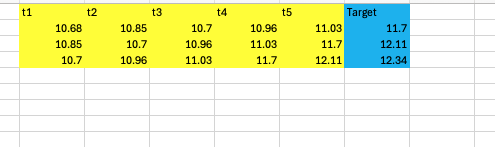

In [20]:
X_train=[]
y_train=[]

X_test=[]
y_test=[]
timesteps=30

In [21]:
for i in range(timesteps, len(training_set)):
  # print(i,i-timesteps)
  X_train.append(training_set[i-timesteps:i, 0])
  y_train.append(training_set[i,0])

In [28]:

for i in range(timesteps, len(test_set)):
  # print(i,i-timesteps)
  X_test.append(test_set[i-timesteps:i, 0])
  y_test.append(test_set[i,0])

In [29]:
for i in range(10):
  print("Training Example: ",i+1)
  print(X_train[i], ":: ", y_train[i])

Training Example:  1
[10.68 10.85 10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67
 11.43 11.37 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36
  9.93  9.87  9.89  9.67  9.54  9.73] ::  9.95
Training Example:  2
[10.85 10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43
 11.37 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93
  9.87  9.89  9.67  9.54  9.73  9.95] ::  10.14
Training Example:  3
[10.7  10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37
 11.35 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93  9.87
  9.89  9.67  9.54  9.73  9.95 10.14] ::  10.13
Training Example:  4
[10.96 11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37 11.35
 11.07 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.36  9.93  9.87  9.89
  9.67  9.54  9.73  9.95 10.14 10.13] ::  10.11
Training Example:  5
[11.03 11.7  12.11 12.34 12.29 12.34 12.01 11.67 11.43 11.37 11.35 11.07
 10.78 10.51 10.94 10.91 10.92 10.77 10.4  10.3

In [30]:
for i in range(10):
  print("Test Exaple: ",i+1)
  print(X_test[i], ":: ", y_test[i])

Test Exaple:  1
[116.33 116.51 116.86 118.16 119.43 119.38 119.93 119.3  119.62 120.24
 120.5  120.09 120.45 120.81 120.1  122.1  122.44 122.35 121.63 121.39
 130.49 129.39 129.19 130.5  132.09 132.22 132.44 132.94 133.82 135.09] ::  136.27
Test Exaple:  2
[116.51 116.86 118.16 119.43 119.38 119.93 119.3  119.62 120.24 120.5
 120.09 120.45 120.81 120.1  122.1  122.44 122.35 121.63 121.39 130.49
 129.39 129.19 130.5  132.09 132.22 132.44 132.94 133.82 135.09 136.27] ::  135.9
Test Exaple:  3
[116.86 118.16 119.43 119.38 119.93 119.3  119.62 120.24 120.5  120.09
 120.45 120.81 120.1  122.1  122.44 122.35 121.63 121.39 130.49 129.39
 129.19 130.5  132.09 132.22 132.44 132.94 133.82 135.09 136.27 135.9 ] ::  135.83
Test Exaple:  4
[118.16 119.43 119.38 119.93 119.3  119.62 120.24 120.5  120.09 120.45
 120.81 120.1  122.1  122.44 122.35 121.63 121.39 130.49 129.39 129.19
 130.5  132.09 132.22 132.44 132.94 133.82 135.09 136.27 135.9  135.83] ::  136.75
Test Exaple:  5
[119.43 119.38 119.93 

In [33]:
X_train=np.array(X_train)
X_test=np.array(X_test)
y_train=np.array(y_train)
y_test=np.array(y_test)

In [34]:
from keras.layers import Dense, Dropout, SimpleRNN
from keras.models import Sequential

In [35]:
# Lets create a simple ANN model
model=Sequential()
model.add(Dense(units=16, activation='relu', input_dim=timesteps))
# model.add(Dense(units=32, activation='relu'))
# model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=1))
model.summary()

C:\Users\karan\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['root_mean_squared_error'])

In [37]:
history=model.fit(X_train,y_train, epochs=10, validation_data=(X_test,y_test))

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 621.5995 - root_mean_squared_error: 24.9319 - val_loss: 55.3174 - val_root_mean_squared_error: 7.4376
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 13.3027 - root_mean_squared_error: 3.6473 - val_loss: 30.3687 - val_root_mean_squared_error: 5.5108
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10.5794 - root_mean_squared_error: 3.2526 - val_loss: 35.9621 - val_root_mean_squared_error: 5.9968
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 10.0800 - root_mean_squared_error: 3.1749 - val_loss: 31.8876 - val_root_mean_squared_error: 5.6469
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.6330 - root_mean_squared_error: 3.1037 - val_loss: 27.5613 - val_root_mean_squared_error: 5.2499
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.2445 - root_mean_squared_error: 3.0405 - val_loss: 27.8184 - val_root_mean_squared_error: 5.2743
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - 

In [38]:
# Lets create a simple RNN model
model_rnn=Sequential()
model_rnn.add(SimpleRNN(units=16,activation='relu', input_shape=(timesteps,1)))
# model_rnn.add(Dense(units=32, activation='relu'))
# model_rnn.add(Dense(units=64, activation='relu'))
model_rnn.add(Dense(units=1))
model_rnn.summary()

C:\Users\karan\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model_rnn.compile(optimizer='adam', loss='mean_squared_error', metrics=['root_mean_squared_error'])
history_rnn=model_rnn.fit(X_train,y_train, epochs=10, validation_data=(X_test,y_test))

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 327.6334 - root_mean_squared_error: 18.1006 - val_loss: 10.4688 - val_root_mean_squared_error: 3.2356
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0429 - root_mean_squared_error: 1.0212 - val_loss: 2.8611 - val_root_mean_squared_error: 1.6915
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9166 - root_mean_squared_error: 0.9574 - val_loss: 2.9252 - val_root_mean_squared_error: 1.7103
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9183 - root_mean_squared_error: 0.9583 - val_loss: 2.9613 - val_root_mean_squared_error: 1.7208
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9238 - root_mean_squared_error: 0.9611 - val_loss: 2.9944 - val_root_mean_squared_error: 1.7304
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9266 - root_mean_squared_error: 0.9626 - val_loss: 2.8502 - val_root_mean_squared_error: 1.6882
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0

In [40]:
y_pred=model_rnn.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


In [41]:
y_pred.shape

(221, 1)

In [42]:
y_pred_ann=model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


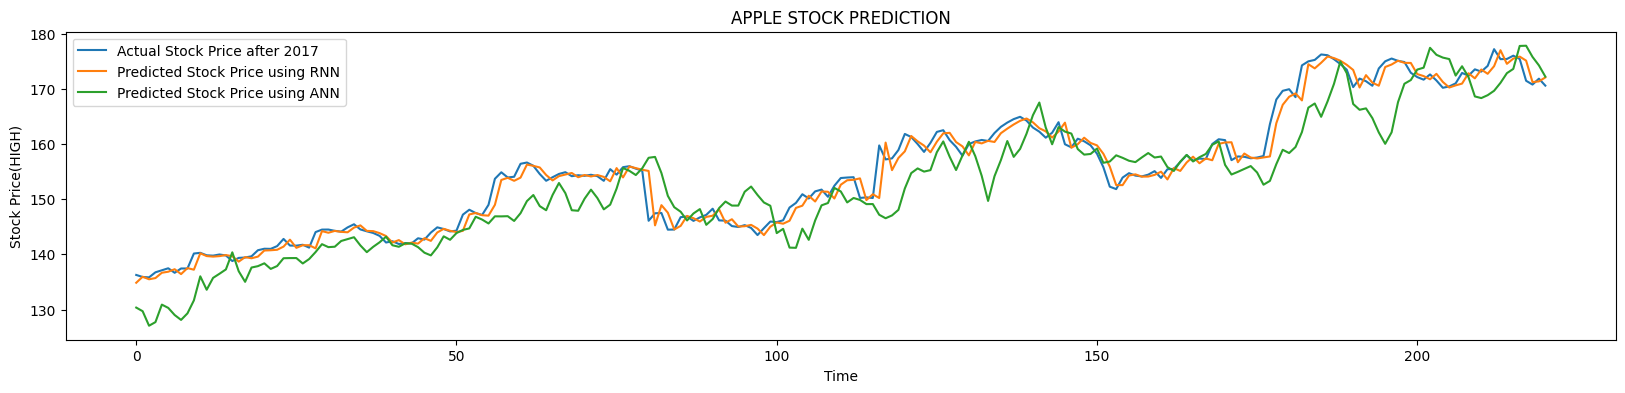

In [43]:
plt.figure(figsize=(20,4))
plt.plot(y_test,label="Actual Stock Price after 2017")
plt.plot(y_pred,label="Predicted Stock Price using RNN")
plt.plot(y_pred_ann,label="Predicted Stock Price using ANN")
plt.title("APPLE STOCK PREDICTION")
plt.xlabel("Time")
plt.ylabel("Stock Price(HIGH)")
plt.legend()
plt.show()

In [44]:
from keras.callbacks import TensorBoard, ModelCheckpoint
import os
import datetime

In [45]:
from math import log
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
%load_ext tensorboard
%tensorboard --logdir {log_dir}

In [46]:
# Lets create a simple ANN model
model_rnn=Sequential()
model_rnn.add(SimpleRNN(units=16,activation='relu', input_shape=(timesteps,1)))
# model_rnn.add(Dense(units=32, activation='relu'))
# model_rnn.add(Dense(units=64, activation='relu'))
model_rnn.add(Dense(units=1))
model_rnn.summary()

checkpoint_filepath="best_model.h5"
model_checkpoint=ModelCheckpoint(filepath=checkpoint_filepath, monitor='val_root_mean_squared_error', save_best_only=True, mode='min')
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

model_rnn.compile(optimizer='adam', loss='mean_squared_error', metrics=['root_mean_squared_error'])
history_rnn=model_rnn.fit(X_train,y_train, epochs=30, validation_data=(X_test,y_test), callbacks=[tensorboard_callback, model_checkpoint])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

...

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3.0547 - root_mean_squared_error: 1.7478 - val_loss: 8.0223 - val_root_mean_squared_error: 2.8324
Epoch 18/30
80/86 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.1777 - root_mean_squared_error: 1.7818

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.0735 - root_mean_squared_error: 1.7532 - val_loss: 7.8826 - val_root_mean_squared_error: 2.8076
Epoch 19/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9940 - root_mean_squared_error: 1.7290

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.0292 - root_mean_squared_error: 1.7405 - val_loss: 7.7314 - val_root_mean_squared_error: 2.7805
Epoch 20/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.0301 - root_mean_squared_error: 1.7407 - val_loss: 8.3089 - val_root_mean_squared_error: 2.8825
Epoch 21/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9899 - root_mean_squared_error: 1.7291 - val_loss: 7.9627 - val_root_mean_squared_error: 2.8218
Epoch 22/30
83/86 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.7601 - root_mean_squared_error: 1.6592

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2.9386 - root_mean_squared_error: 1.7142 - val_loss: 7.5964 - val_root_mean_squared_error: 2.7561
Epoch 23/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.9479 - root_mean_squared_error: 1.7170 - val_loss: 7.6593 - val_root_mean_squared_error: 2.7675
Epoch 24/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.9100 - root_mean_squared_error: 1.7059 - val_loss: 7.9235 - val_root_mean_squared_error: 2.8149
Epoch 25/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.9122 - root_mean_squared_error: 1.7065 - val_loss: 10.2089 - val_root_mean_squared_error: 3.1951
Epoch 26/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.8974 - root_mean_squared_error: 1.7022 - val_loss: 9.4898 - val_root_mean_squared_error: 3.0806
Epoch 27/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2.8822 - root_mean_squared_error: 1.6977 - val_loss: 8.2016 - val_root_mean_squared_error: 2.8638
Epoch 28/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.885

86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7907 - root_mean_squared_error: 1.6705 - val_loss: 7.3625 - val_root_mean_squared_error: 2.7134
Epoch 29/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.6097 - root_mean_squared_error: 1.6155 - val_loss: 7.7513 - val_root_mean_squared_error: 2.7841
Epoch 30/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.6355 - root_mean_squared_error: 1.6234 - val_loss: 8.4475 - val_root_mean_squared_error: 2.9065
